In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

In [2]:
BSF_ROOT = Path("/ebs/home/lily_switch_box/buildstock-fetch")
RDP_ROOT = Path("/ebs/home/lily_switch_box/rate-design-platform")

# Both repos have a top-level `utils/` package — only one can be cached as `utils`.
# Put buildstock-fetch first so `from utils import ev_utils` works.
# Import rate-design-platform's utils.loads via importlib in the next cell.
for root in (RDP_ROOT, BSF_ROOT):
    root_str = str(root)
    if root_str in sys.path:
        sys.path.remove(root_str)
sys.path.insert(0, str(BSF_ROOT))
sys.path.insert(1, str(RDP_ROOT))

In [3]:
from data.eia.hourly_loads.eia_region_config import get_aws_storage_options

# ── Edit these ──────────────────────────────────────────────────────────────
STATE = "MD"
UPGRADE = "00"  # try "02" later for the heat-pump upgrade
USE_LOCAL = True  # False → read from s3://data.sb/...
USE_SB = True  # False → raw NREL metadata.parquet
SEED = 42
# ────────────────────────────────────────────────────────────────────────────

RELEASE = "res_2024_amy2018_2"
RELEASE_SB = f"{RELEASE}_sb"
PATH_LOCAL = Path("/ebs/data/nrel/resstock")
PATH_S3 = "s3://data.sb/nrel/resstock"

release_name = RELEASE_SB if USE_SB else RELEASE
resstock_base = PATH_LOCAL / release_name if USE_LOCAL else f"{PATH_S3}/{release_name}"
storage_options = get_aws_storage_options() if not USE_LOCAL else None
meta_filename = "metadata-sb.parquet" if USE_SB else "metadata.parquet"

path_metadata = f"{resstock_base}/metadata/state={STATE}/upgrade={UPGRADE}/{meta_filename}"
path_loads_dir = f"{resstock_base}/load_curve_hourly/state={STATE}/upgrade={UPGRADE}"

print(f"Metadata:  {path_metadata}")
print(f"Loads dir: {path_loads_dir}")

Metadata:  /ebs/data/nrel/resstock/res_2024_amy2018_2_sb/metadata/state=MD/upgrade=00/metadata-sb.parquet
Loads dir: /ebs/data/nrel/resstock/res_2024_amy2018_2_sb/load_curve_hourly/state=MD/upgrade=00


In [4]:
# load metadata
kwargs = {"storage_options": storage_options} if storage_options else {}
metadata = pl.read_parquet(path_metadata, **kwargs)

print(f"{metadata.height:,} buildings × {metadata.width} columns")
metadata.head(3)

9,996 buildings × 188 columns


upgrade,weight,in.sqft,in.representative_income,in.ahs_region,in.aiannh_area,in.area_median_income,in.ashrae_iecc_climate_zone_2004,in.ashrae_iecc_climate_zone_2004_2_a_split,in.bathroom_spot_vent_hour,in.battery,in.bedrooms,in.building_america_climate_zone,in.cec_climate_zone,in.ceiling_fan,in.census_division,in.census_division_recs,in.census_region,in.city,in.clothes_dryer,in.clothes_dryer_usage_level,in.clothes_washer,in.clothes_washer_presence,in.clothes_washer_usage_level,in.cooking_range,in.cooking_range_usage_level,in.cooling_setpoint,in.cooling_setpoint_has_offset,in.cooling_setpoint_offset_magnitude,in.cooling_setpoint_offset_period,in.corridor,in.county,in.county_and_puma,in.county_name,in.dehumidifier,in.dishwasher,in.dishwasher_usage_level,…,in.solar_hot_water,in.state,in.tenure,in.units_represented,in.usage_level,in.utility_bill_electricity_fixed_charges,in.utility_bill_electricity_marginal_rates,in.utility_bill_fuel_oil_fixed_charges,in.utility_bill_fuel_oil_marginal_rates,in.utility_bill_natural_gas_fixed_charges,in.utility_bill_natural_gas_marginal_rates,in.utility_bill_propane_fixed_charges,in.utility_bill_propane_marginal_rates,in.utility_bill_scenario_names,in.utility_bill_simple_filepaths,in.vacancy_status,in.vintage,in.vintage_acs,in.water_heater_efficiency,in.water_heater_fuel,in.water_heater_in_unit,in.water_heater_location,in.weather_file_city,in.weather_file_latitude,in.weather_file_longitude,in.window_areas,in.windows,bldg_id,postprocess_group.has_hp,postprocess_group.heating_type,postprocess_group.heating_type_v2,heats_with_electricity,heats_with_natgas,heats_with_oil,heats_with_propane,has_natgas_connection,mf_non_hvac_electricity_adjusted
i64,f64,i64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,i64,str,i64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str,str,i64,bool,str,str,bool,bool,bool,bool,bool,bool
0,252.301639,1682,108692.0,"""Non-CBSA South Atlantic""","""No""","""120-150%""","""4A""","""4A""","""Hour6""","""None""","""3""","""Mixed-Humid""","""None""","""Standard Efficiency""","""South Atlantic""","""South Atlantic""","""South""","""In another census Place""","""None""","""120% Usage""","""None""","""None""","""120% Usage""","""Electric Resistance""","""120% Usage""","""72F""","""No""","""0F""","""None""","""Double-Loaded Interior""","""G2400030""","""G2400030, G24001202""","""Anne Arundel County""","""None""","""290 Rated kWh""","""120% Usage""",…,"""None""","""MD""","""Renter""",1,"""High""",10,0.130352,"""0""","""3.219615385""","""11.25""","""1.217491908""","""0""","""3.224769231""","""Utility Rates - Fixed + Variab…","""data/simple_rates/State.tsv""","""Occupied""","""1980s""","""1980-99""","""Electric Standard""","""Electricity""","""No""","""None""","""Baltimore Washingto""",39.17,-76.68,"""F18 B18 L18 R18""","""Single, Clear, Non-metal""",185465,false,"""electrical_resistance""","""electrical_resistance""",true,false,false,false,false,true
0,252.301639,854,108692.0,"""CBSA Washington-Arlington-Alex…","""No""","""100-120%""","""4A""","""4A""","""Hour22""","""None""","""2""","""Mixed-Humid""","""None""","""None""","""South Atlantic""","""South Atlantic""","""South""","""In another census Place""","""None""","""100% Usage""","""None""","""None""","""100% Usage""","""Electric Resistance""","""100% Usage""","""68F""","""No""","""0F""","""None""","""Double-Loaded Interior""","""G2400330""","""G2400330, G24001102""","""Prince George's County""","""None""","""318 Rated kWh""","""100% Usage""",…,"""None""","""MD""","""Renter""",1,"""Medium""",10,0.130352,"""0""","""3.219615385""","""11.25""","""1.217491908""","""0""","""3.224769231""","""Utility Rates - Fixed + Variab…","""data/simple_rates/State.tsv""","""Occupied""","""1970s""","""1960-79""","""Electric Heat Pump, 50 gal, 3.…","""Electricity""","""No""","""None""","""Andrews Afb Camp Sp""",38.82,-76.85,"""

Simple EV charging model:
- Every household has 1 EV with the same battery capacity
- Every household has the same EV charger
- Every household has the same miles traveled (30 miles per day at 0.3 kWh/mile → needs to charge 9 kWh at night)
- Assume same electricity rate for everyone and it is constant by hour
- Every household does all their charging at home (no differentiation by hour because rates are held constant)

In [5]:
# EV Assumptions
EVS_PER_HOUSEHOLD = 1
DAILY_MILES = 30
KWH_PER_MILE = 0.30
DAYS_PER_YEAR = 365
daily_kwh_per_ev = DAILY_MILES * KWH_PER_MILE
annual_kwh_per_ev = daily_kwh_per_ev * DAYS_PER_YEAR

ev_model_simple = (
    metadata.select(
        "bldg_id",
        "weight",
        "in.county_name",
        "in.income",
        "in.puma_metro_status",
        "in.utility_bill_electricity_marginal_rates",
    )
    .rename({"in.utility_bill_electricity_marginal_rates": "rate_per_kwh"})
    .with_columns(
        pl.lit(EVS_PER_HOUSEHOLD).alias("ev_count"),
        pl.lit(daily_kwh_per_ev).alias("daily_ev_kwh"),
        pl.lit(annual_kwh_per_ev).alias("annual_ev_kwh_per_ev"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh_per_ev") * pl.col("ev_count")).alias("annual_ev_kwh"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") * pl.col("rate_per_kwh")).alias("annual_ev_cost_usd"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") * pl.col("weight")).alias("weighted_annual_ev_kwh"),
        (pl.col("annual_ev_cost_usd") * pl.col("weight")).alias("weighted_annual_ev_cost_usd"),
    )
)

ev_model_simple.head(5)

bldg_id,weight,in.county_name,in.income,in.puma_metro_status,rate_per_kwh,ev_count,daily_ev_kwh,annual_ev_kwh_per_ev,annual_ev_kwh,annual_ev_cost_usd,weighted_annual_ev_kwh,weighted_annual_ev_cost_usd
i64,f64,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64
185465,252.301639,"""Anne Arundel County""","""100000-119999""","""In metro area, not/partially i…",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451
381889,252.301639,"""Prince George's County""","""100000-119999""","""In metro area, not/partially i…",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451
294937,252.301639,"""Baltimore city""","""100000-119999""","""In metro area, principal city""",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451
310780,252.301639,"""Baltimore County""","""<10000""","""In metro area, not/partially i…",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451
313723,252.301639,"""Harford County""","""50000-59999""","""In metro area, not/partially i…",0.130352,1,9.0,3285.0,3285.0,428.207506,828810.883229,108037.455451


Slightly more complicated model:
- instead of assuming every household has one EV, predict the number of vehicles for each household using predict_num_vehicles() and assume they are all EVs
- sample trip schedules according to methods in ev_demand.py
- for each vehicle, build an 8760-row hourly schedule of when the vehicle is at home vs away; assume it can charge whenever it is at home

To get this running, need to get data using command line arguments (PUMS is used to predict the number of vehicles per household):
- cd ~/buildstock-fetch
- uv sync --extra dev-utils          # scikit-learn for the ownership model
- just download-pums-md              # writes utils/ev_data/inputs/MD_2021_pums_PUMA_HINCP_VEH_NP.csv
- just download-nhts                 # for Phase 2 (trip schedules)

In [6]:
from utils import ev_utils

PUMS_PATH = BSF_ROOT / "utils/ev_data/inputs/MD_2021_pums_PUMA_HINCP_VEH_NP.csv"
NHTS_PATH = BSF_ROOT / "utils/ev_data/inputs/NHTS_v2_1_trip_surveys.csv"

if not PUMS_PATH.exists():
    raise FileNotFoundError(f"Missing {PUMS_PATH}. Run: just download-pums-md")
if not NHTS_PATH.exists():
    raise FileNotFoundError(f"Missing {NHTS_PATH}. Run: just download-nhts")

# load sample of metadata
# None = all MD buildings that pass load_metadata filters (~9,002); int = head(N) for fast iteration
N_VEH_SAMPLE: int | None = 500
metadata_slim = ev_utils.load_metadata(path_metadata, STATE)
if N_VEH_SAMPLE is not None:
    metadata_slim = metadata_slim.join(metadata.head(N_VEH_SAMPLE).select("bldg_id"), on="bldg_id")
metadata_sample = metadata.join(metadata_slim.select("bldg_id"), on="bldg_id")

# load PUMS data
pums_df = ev_utils.load_pums_data(str(PUMS_PATH), path_metadata)

print(f"PUMS households: {pums_df.height:,}")
print(f"ResStock sample:   {metadata_slim.height:,}")
print(pums_df.group_by("vehicles").agg(pl.len().alias("n")).sort("vehicles"))

# load NHTS data
nhts_df = ev_utils.load_nhts_data(str(NHTS_PATH), STATE)
print(f"NHTS trips (MD census division): {nhts_df.height:,}")

PUMS households: 23,776
ResStock sample:   449
shape: (7, 2)
┌──────────┬──────┐
│ vehicles ┆ n    │
│ ---      ┆ ---  │
│ i64      ┆ u32  │
╞══════════╪══════╡
│ 0        ┆ 1578 │
│ 1        ┆ 7449 │
│ 2        ┆ 9240 │
│ 3        ┆ 3675 │
│ 4        ┆ 1302 │
│ 5        ┆ 382  │
│ 6        ┆ 150  │
└──────────┴──────┘
NHTS trips (MD census division): 5,352


Daily miles per vehicle (NHTS survey vehicle-days, MD census division)


day_type,n_vehicle_days,mean,median,std,min,p10,p25,p75,p90,p95,max
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""weekday""",1072,31.097848,18.52082,57.703801,0.0,4.072716,9.30578,35.968303,60.829086,85.69422,1066.750777
"""weekend""",395,43.491934,15.200746,95.437183,0.529521,3.493474,7.462399,38.361715,85.39652,171.448726,1052.331262


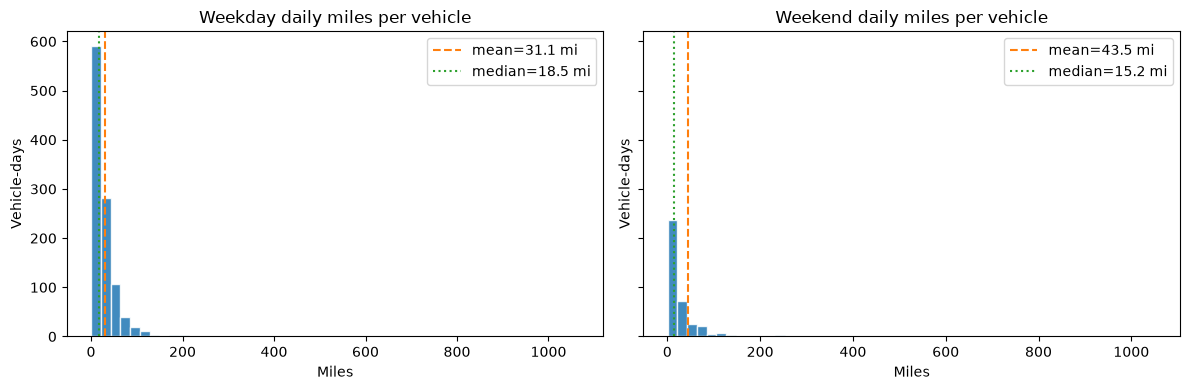

In [7]:
# Sum trip miles to get daily miles per surveyed vehicle-day
trip_cols = ["hh_vehicle_id", "vehicle_id", "weekday", "start_time", "end_time", "miles_driven"]
nhts_trips = nhts_df.unique(subset=trip_cols)  # NHTS has lots of duplicate rows

daily_miles_by_vehicle = (
    nhts_trips.group_by("hh_vehicle_id", "vehicle_id", "weekday")
    .agg(pl.col("miles_driven").sum().alias("daily_miles"))
    .with_columns(
        pl.when(pl.col("weekday") == 2).then(pl.lit("weekday")).otherwise(pl.lit("weekend")).alias("day_type")
    )
)

daily_miles_stats = (
    daily_miles_by_vehicle.group_by("day_type")
    .agg(
        pl.len().alias("n_vehicle_days"),
        pl.col("daily_miles").mean().alias("mean"),
        pl.col("daily_miles").median().alias("median"),
        pl.col("daily_miles").std().alias("std"),
        pl.col("daily_miles").min().alias("min"),
        pl.col("daily_miles").quantile(0.10).alias("p10"),
        pl.col("daily_miles").quantile(0.25).alias("p25"),
        pl.col("daily_miles").quantile(0.75).alias("p75"),
        pl.col("daily_miles").quantile(0.90).alias("p90"),
        pl.col("daily_miles").quantile(0.95).alias("p95"),
        pl.col("daily_miles").max().alias("max"),
    )
    .sort("day_type")
)

print("Daily miles per vehicle (NHTS survey vehicle-days, MD census division)")
display(daily_miles_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, weekday_flag, label in zip(axes, [2, 1], ["Weekday", "Weekend"], strict=True):
    miles = daily_miles_by_vehicle.filter(pl.col("weekday") == weekday_flag)["daily_miles"].to_numpy()
    ax.hist(miles, bins=50, edgecolor="white", alpha=0.85)
    ax.set_title(f"{label} daily miles per vehicle")
    ax.set_xlabel("Miles")
    ax.set_ylabel("Vehicle-days")
    ax.axvline(miles.mean(), color="C1", ls="--", label=f"mean={miles.mean():.1f} mi")
    ax.axvline(np.median(miles), color="C2", ls=":", label=f"median={np.median(miles):.1f} mi")
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
# Filter nhts_df to only include vehicles with daily miles between p10 and p90.
# If a vehicle has both weekday and weekend profiles, both must pass.
# If it only has one profile, only that one is checked.
weekday_bounds = daily_miles_stats.filter(pl.col("day_type") == "weekday").select("p10", "p90").row(0, named=True)
weekend_bounds = daily_miles_stats.filter(pl.col("day_type") == "weekend").select("p10", "p90").row(0, named=True)

weekday_miles = daily_miles_by_vehicle.filter(pl.col("weekday") == 2).select(
    "hh_vehicle_id",
    "vehicle_id",
    pl.col("daily_miles").alias("weekday_daily_miles"),
)
weekend_miles = daily_miles_by_vehicle.filter(pl.col("weekday") == 1).select(
    "hh_vehicle_id",
    "vehicle_id",
    pl.col("daily_miles").alias("weekend_daily_miles"),
)

vehicle_miles = weekday_miles.join(
    weekend_miles,
    on=["hh_vehicle_id", "vehicle_id"],
    how="full",
    coalesce=True,
)

vehicles_in_range = vehicle_miles.filter(
    pl.when(pl.col("weekday_daily_miles").is_not_null() & pl.col("weekend_daily_miles").is_not_null())
    .then(
        pl.col("weekday_daily_miles").is_between(weekday_bounds["p10"], weekday_bounds["p90"])
        & pl.col("weekend_daily_miles").is_between(weekend_bounds["p10"], weekend_bounds["p90"])
    )
    .when(pl.col("weekday_daily_miles").is_not_null())
    .then(pl.col("weekday_daily_miles").is_between(weekday_bounds["p10"], weekday_bounds["p90"]))
    .otherwise(pl.col("weekend_daily_miles").is_between(weekend_bounds["p10"], weekend_bounds["p90"]))
)

n_trips_before = nhts_df.height
n_vehicles_before = vehicle_miles.height
n_vehicles_after = vehicles_in_range.height

nhts_df = nhts_df.join(
    vehicles_in_range.select("hh_vehicle_id", "vehicle_id"),
    on=["hh_vehicle_id", "vehicle_id"],
    how="inner",
)

print("Daily miles bounds used for filtering")
display(
    pl.DataFrame({
        "day_type": ["weekday", "weekend"],
        "p10": [weekday_bounds["p10"], weekend_bounds["p10"]],
        "p90": [weekday_bounds["p90"], weekend_bounds["p90"]],
    })
)
print(f"Vehicles kept: {n_vehicles_after:,} / {n_vehicles_before:,}")
print(f"NHTS trip rows kept: {nhts_df.height:,} / {n_trips_before:,}")

Daily miles bounds used for filtering


day_type,p10,p90
str,f64,f64
"""weekday""",4.072716,60.829086
"""weekend""",3.493474,85.39652


Vehicles kept: 1,126 / 1,418
NHTS trip rows kept: 4,310 / 5,352


In [9]:
from utils.ev_demand import EVDemandCalculator, summarize_nhts_match_catalog

# now match vehicles to buildings
SCHEDULE_START = datetime(2024, 1, 1)
SCHEDULE_END = datetime(2024, 12, 31)
EV_ADOPTION_RATE = 1.0  # fraction of predicted vehicles treated as EVs (assume 1 for now)

# create EV demand calculator
calculator = EVDemandCalculator(
    metadata_df=metadata_slim,
    nhts_df=nhts_df,
    pums_df=pums_df,
    start_date=SCHEDULE_START,
    end_date=SCHEDULE_END,
    random_state=SEED,
)

# predict number of vehicles per building
bldg_vehicles = calculator.predict_num_vehicles()
print("Predicted vehicles per building")
print(bldg_vehicles.group_by("vehicles").agg(pl.len().alias("buildings")).sort("vehicles"))
print(f"Mean vehicles/household: {bldg_vehicles['vehicles'].mean():.2f}")

# diagnoistics to see if there are empty matches or matches with missing weekday or weekend profiles
vehicle_profiles, nhts_match_catalog = calculator.sample_vehicle_profiles(bldg_vehicles, nhts_df, return_catalog=True)
print(f"Vehicle profiles sampled: {len(vehicle_profiles):,}")

print("\nNHTS match catalog (vehicle slots with missing NHTS match or trip profiles)")
match_summary = summarize_nhts_match_catalog(nhts_match_catalog)
display(match_summary)

print("\nBy match_type (vehicle slots)")
display(
    nhts_match_catalog.group_by("match_type")
    .agg(
        pl.len().alias("vehicle_slots"),
        (~pl.col("nhts_vehicle_matched")).sum().alias("missing_nhts_match"),
        pl.col("has_weekday_trips").not_().sum().alias("missing_weekday_profile"),
        pl.col("has_weekend_trips").not_().sum().alias("missing_weekend_profile"),
    )
    .sort("vehicle_slots", descending=True)
)

print("\nTop 10 most-matched NHTS vehicles (by predicted vehicle slots assigned)")
nhts_vehicle_match_counts = (
    nhts_match_catalog.filter(pl.col("nhts_vehicle_matched"))
    .group_by("matched_hh_vehicle_id")
    .agg(pl.len().alias("match_count"))
    .sort("match_count", descending=True)
)
print(f"Unique NHTS vehicles matched: {nhts_vehicle_match_counts.height:,}")
display(nhts_vehicle_match_counts.head(10))

gap_rows = nhts_match_catalog.filter(
    ~pl.col("nhts_vehicle_matched") | ~pl.col("has_weekday_trips") | ~pl.col("has_weekend_trips")
)
print(f"\nVehicle slots with any gap: {gap_rows.height:,} / {nhts_match_catalog.height:,}")
display(gap_rows.head(20))

2026-06-22 15:51:27,105 - INFO - Vehicle ownership model not fitted yet. Fitting model...
2026-06-22 15:51:27,145 - INFO - Sampling vehicle profiles for 449 buildings...
2026-06-22 15:51:27,147 - INFO - Preparing NHTS data cache to optimize matching...
2026-06-22 15:51:27,163 - INFO - NHTS cache prepared successfully


Predicted vehicles per building
shape: (3, 2)
┌──────────┬───────────┐
│ vehicles ┆ buildings │
│ ---      ┆ ---       │
│ i64      ┆ u32       │
╞══════════╪═══════════╡
│ 0        ┆ 1         │
│ 1        ┆ 155       │
│ 2        ┆ 293       │
└──────────┴───────────┘
Mean vehicles/household: 1.65


2026-06-22 15:51:27,384 - INFO - Building progress: 449/449 (100.0%)
2026-06-22 15:51:27,385 - INFO - Generated 741 vehicle profiles from 449 buildings


Vehicle profiles sampled: 741

NHTS match catalog (vehicle slots with missing NHTS match or trip profiles)


metric,count,share_of_vehicle_slots
str,i64,f64
"""vehicle_slots""",741,1.0
"""missing_nhts_vehicle_match""",0,0.0
"""missing_weekday_trip_profile""",173,0.233468
"""missing_weekend_trip_profile""",545,0.735493
"""missing_both_trip_profiles""",0,0.0
"""buildings_with_any_gap""",445,0.993304


...

match_type,vehicle_slots,missing_nhts_match,missing_weekday_profile,missing_weekend_profile
str,u32,u32,u32,u32
"""exact""",717,0,163,531
"""income_only""",18,0,4,14
"""income_occupants""",6,0,6,0



Top 10 most-matched NHTS vehicles (by predicted vehicle slots assigned)
Unique NHTS vehicles matched: 484


matched_hh_vehicle_id,match_count
str,u32
"""900012648901""",8
"""900017425402""",5
"""900007546503""",5
"""900011411301""",4
"""900012641301""",4
"""900016464903""",4
"""900012842702""",4
"""900016612302""",4
"""900012842701""",4



Vehicle slots with any gap: 718 / 741


bldg_id,vehicle_slot,predicted_vehicles,match_type,nhts_vehicle_matched,matched_hh_vehicle_id,has_weekday_trips,has_weekend_trips,weekday_trip_count,weekend_trip_count
i64,i64,i64,str,bool,str,bool,bool,i64,i64
185465,1,2,"""exact""",true,"""900004921702""",false,true,0,5
185465,2,2,"""exact""",true,"""900021021802""",true,false,4,0
381889,1,2,"""exact""",true,"""900005026401""",true,false,2,0
381889,2,2,"""exact""",true,"""900001574702""",false,true,0,4
294937,1,1,"""exact""",true,"""900001551401""",true,false,2,0
…,…,…,…,…,…,…,…,…,…
435023,1,2,"""income_only""",true,"""900021581801""",true,false,15,0
435023,2,2,"""income_only""",true,"""900007616701""",true,false,2,0
440150,1,1,"""exact""",true,"""900021518201""",true,false,2,0


In [10]:
# print example vehicle profile
example_key = next(k for k, p in vehicle_profiles.items() if p.weekday_miles)
example_vehicle = vehicle_profiles[example_key]
print(
    f"Example bldg {example_vehicle.bldg_id} vehicle {example_vehicle.vehicle_id}: "
    f"{len(example_vehicle.weekday_miles)} weekday trips, "
    f"{len(example_vehicle.weekend_miles)} weekend trips"
)

# generate annual trip schedules for each vehicle
trip_schedules = calculator._generate_annual_trip_schedule(vehicle_profiles)
print(f"Trip schedule rows: {trip_schedules.height:,}")
print(trip_schedules.head(5))

2026-06-22 15:51:31,481 - INFO - Processing 741 vehicle profiles...
2026-06-22 15:51:31,481 - INFO - Using parallel processing with all available workers


Example bldg 185465 vehicle 2: 4 weekday trips, 0 weekend trips


2026-06-22 15:51:59,227 - INFO - Progress: 741/741 (100.0%)
2026-06-22 15:51:59,228 - INFO - Generated 556751 trip schedules from 741 vehicle profiles


Trip schedule rows: 556,751
shape: (5, 6)
┌─────────┬────────────┬─────────────────────┬────────────────┬──────────────┬──────────────┐
│ bldg_id ┆ vehicle_id ┆ date                ┆ departure_hour ┆ arrival_hour ┆ miles_driven │
│ ---     ┆ ---        ┆ ---                 ┆ ---            ┆ ---          ┆ ---          │
│ i64     ┆ i64        ┆ datetime[μs]        ┆ i64            ┆ i64          ┆ f64          │
╞═════════╪════════════╪═════════════════════╪════════════════╪══════════════╪══════════════╡
│ 185465  ┆ 1          ┆ 2024-01-06 00:00:00 ┆ 12             ┆ 13           ┆ 0.0          │
│ 185465  ┆ 1          ┆ 2024-01-06 00:00:00 ┆ 16             ┆ 17           ┆ 7.222011     │
│ 185465  ┆ 1          ┆ 2024-01-06 00:00:00 ┆ 18             ┆ 19           ┆ 5.38069      │
│ 185465  ┆ 1          ┆ 2024-01-06 00:00:00 ┆ 14             ┆ 15           ┆ 9.633109     │
│ 185465  ┆ 1          ┆ 2024-01-06 00:00:00 ┆ 20             ┆ 21           ┆ 2.782145     │
└─────────┴───────

In [11]:
# get statistics on annual miles and apply a flat rate
bldg_annual_miles = trip_schedules.group_by("bldg_id").agg(
    pl.col("miles_driven").sum().alias("annual_miles"),
    pl.col("miles_driven").mean().alias("mean_miles_per_trip"),
    pl.len().alias("trip_count"),
)

vehicle_annual_miles = trip_schedules.group_by("bldg_id", "vehicle_id").agg(
    pl.col("miles_driven").sum().alias("annual_miles"),
    pl.col("miles_driven").mean().alias("mean_miles_per_trip"),
    pl.len().alias("trip_count"),
)

bldg_weights = metadata_sample.select("bldg_id", "weight")

vehicle_annual_miles_all = (
    bldg_vehicles.filter(pl.col("vehicles") > 0)
    .with_columns(pl.int_ranges(pl.lit(1), pl.col("vehicles") + 1).alias("vehicle_id"))
    .explode("vehicle_id")
    .join(vehicle_annual_miles, on=["bldg_id", "vehicle_id"], how="left")
    .join(bldg_weights, on="bldg_id")
    .with_columns(pl.col("annual_miles").fill_null(0.0))
)


def weighted_miles_summary(df: pl.DataFrame, value_col: str, weight_col: str) -> pl.DataFrame:
    """Weighted mean/median/min/max using ResStock sampling weights."""
    values = df[value_col].to_numpy()
    weights = df[weight_col].to_numpy()
    total_w = weights.sum()
    wmean = float((values * weights).sum() / total_w)
    order = np.argsort(values)
    sorted_values = values[order]
    sorted_weights = weights[order]
    cum_w = np.cumsum(sorted_weights)

    def wquantile(q: float) -> float:
        if q <= 0:
            return float(sorted_values[0])
        if q >= 1:
            return float(sorted_values[-1])
        target = q * total_w
        idx = min(int(np.searchsorted(cum_w, target, side="left")), len(sorted_values) - 1)
        return float(sorted_values[idx])

    return pl.DataFrame({
        "mean": [wmean],
        "median": [wquantile(0.5)],
        "min": [wquantile(0.0)],
        "max": [wquantile(1.0)],
    })


ev_model_nhts = (
    metadata_sample.select(
        "bldg_id",
        "weight",
        "in.county_name",
        "in.income",
        "in.utility_bill_electricity_marginal_rates",
    )
    .join(bldg_vehicles.select("bldg_id", "vehicles"), on="bldg_id")
    .join(bldg_annual_miles, on="bldg_id", how="left")
    .with_columns(
        pl.col("annual_miles").fill_null(0.0),
        pl.col("trip_count").fill_null(0),
    )
    .rename({"in.utility_bill_electricity_marginal_rates": "rate_per_kwh"})
    .with_columns(
        (pl.col("vehicles") * EV_ADOPTION_RATE).alias("ev_count"),
    )
    .with_columns(
        (pl.col("annual_miles") * KWH_PER_MILE * EV_ADOPTION_RATE).alias("annual_ev_kwh"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") / DAYS_PER_YEAR).alias("daily_ev_kwh"),
        (pl.col("annual_ev_kwh") / pl.col("ev_count").clip(lower_bound=1)).alias("annual_ev_kwh_per_ev"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") * pl.col("rate_per_kwh")).alias("annual_ev_cost_usd"),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") * pl.col("weight")).alias("weighted_annual_ev_kwh"),
        (pl.col("annual_ev_cost_usd") * pl.col("weight")).alias("weighted_annual_ev_cost_usd"),
    )
)

print("Miles per building (sample, unweighted)")
print(
    ev_model_nhts.select(
        pl.col("annual_miles").mean().alias("mean"),
        pl.col("annual_miles").median().alias("median"),
        pl.col("annual_miles").min().alias("min"),
        pl.col("annual_miles").max().alias("max"),
    )
)
print("\nMiles per building (ResStock weight — each row = one dwelling in sample)")
print(weighted_miles_summary(ev_model_nhts, "annual_miles", "weight"))

print("\nMiles per vehicle (sample, unweighted — vehicles with trip schedules only)")
print(
    vehicle_annual_miles.select(
        pl.col("annual_miles").mean().alias("mean"),
        pl.col("annual_miles").median().alias("median"),
        pl.col("annual_miles").min().alias("min"),
        pl.col("annual_miles").max().alias("max"),
    )
)
print("\nMiles per vehicle (ResStock weight — each row = one predicted EV slot)")
print(weighted_miles_summary(vehicle_annual_miles_all, "annual_miles", "weight"))
print(f"Flat-assumption benchmark: {DAILY_MILES * DAYS_PER_YEAR:.0f} mi/EV/year")

print("\nComparison (same buildings, unweighted annual_ev_kwh totals)")
sample_ids = metadata_sample.select("bldg_id")
simple_on_sample = ev_model_simple.join(sample_ids, on="bldg_id")
pums_flat_on_sample = (
    simple_on_sample.drop(
        "ev_count",
        "daily_ev_kwh",
        "annual_ev_kwh_per_ev",
        "annual_ev_kwh",
        "annual_ev_cost_usd",
        "weighted_annual_ev_kwh",
        "weighted_annual_ev_cost_usd",
    )
    .join(bldg_vehicles.select("bldg_id", "vehicles"), on="bldg_id")
    .with_columns((pl.col("vehicles") * EV_ADOPTION_RATE * annual_kwh_per_ev).alias("annual_ev_kwh"))
)
print(f"  Simple (1 EV, flat miles):    {simple_on_sample['annual_ev_kwh'].sum():,.0f} kWh")
print(f"  PUMS counts, flat miles:      {pums_flat_on_sample['annual_ev_kwh'].sum():,.0f} kWh")
print(f"  PUMS + NHTS trip schedules:   {ev_model_nhts['annual_ev_kwh'].sum():,.0f} kWh")

ev_model_nhts.head(10)

Miles per building (sample, unweighted)
shape: (1, 4)
┌─────────────┬─────────────┬─────┬──────────────┐
│ mean        ┆ median      ┆ min ┆ max          │
│ ---         ┆ ---         ┆ --- ┆ ---          │
│ f64         ┆ f64         ┆ f64 ┆ f64          │
╞═════════════╪═════════════╪═════╪══════════════╡
│ 8879.791398 ┆ 7629.957699 ┆ 0.0 ┆ 41446.988259 │
└─────────────┴─────────────┴─────┴──────────────┘

Miles per building (ResStock weight — each row = one dwelling in sample)
shape: (1, 4)
┌─────────────┬─────────────┬─────┬──────────────┐
│ mean        ┆ median      ┆ min ┆ max          │
│ ---         ┆ ---         ┆ --- ┆ ---          │
│ f64         ┆ f64         ┆ f64 ┆ f64          │
╞═════════════╪═════════════╪═════╪══════════════╡
│ 8879.791398 ┆ 7629.957699 ┆ 0.0 ┆ 41446.988259 │
└─────────────┴─────────────┴─────┴──────────────┘

Miles per vehicle (sample, unweighted — vehicles with trip schedules only)
shape: (1, 4)
┌─────────────┬─────────────┬────────────┬────────────

bldg_id,weight,in.county_name,in.income,rate_per_kwh,vehicles,annual_miles,mean_miles_per_trip,trip_count,ev_count,annual_ev_kwh,daily_ev_kwh,annual_ev_kwh_per_ev,annual_ev_cost_usd,weighted_annual_ev_kwh,weighted_annual_ev_cost_usd
i64,f64,str,str,f64,i64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64
185465,252.301639,"""Anne Arundel County""","""100000-119999""",0.130352,2,3781.980432,2.411977,1568,2.0,1134.59413,3.108477,567.297065,147.897024,286259.958219,37314.661414
381889,252.301639,"""Prince George's County""","""100000-119999""",0.130352,2,3349.821346,3.56364,940,2.0,1004.946404,2.753278,502.473202,130.997136,253549.624483,33050.792182
294937,252.301639,"""Baltimore city""","""100000-119999""",0.130352,1,4541.82593,8.667607,524,1.0,1362.547779,3.733008,1362.547779,177.61132,343773.037501,44811.627086
310780,252.301639,"""Baltimore County""","""<10000""",0.130352,1,13978.264978,10.971951,1274,1.0,4193.479493,11.488985,4193.479493,546.629953,1.0580e6,137915.632865
313723,252.301639,"""Harford County""","""50000-59999""",0.130352,1,7282.390837,13.897692,524,1.0,2184.717251,5.985527,2184.717251,284.783052,551207.74258,71851.230647
389682,252.301639,"""Baltimore County""","""45000-49999""",0.130352,1,5519.58109,3.100888,1780,1.0,1655.874327,4.536642,1655.874327,215.847128,417779.80624,54458.584122
420703,252.301639,"""Howard County""","""30000-34999""",0.130352,1,3998.616753,5.087299,786,1.0,1199.585026,3.286534,1199.585026,156.36874,302657.267827,39452.089435
421768,252.301639,"""Anne Arundel County""","""200000+""",0.130352,2,6996.18272,3.337873,2096,2.0,2098.854816,5.750287,1049.427408,273.590681,529544.509528,69027.377072
429764,252.301639,"""Montgomery County""","""180000-199999""",0.130352,2,4700.145265,6.420963,732,2.0,1410.043579,3.863133,705.02179,183.80251,355756.305771,46373.674398


Now keep track of hourly state of charge under the assumptions that:
- every EV has a capacity of 90 kWh and is fully charged on Jan 1
- every EV requires 0.3 kWh/mile of driving and this is spread evenly over the trip duration
- every household with an EV has a level 2 charger with power 7.2 kW
- the EV charges whenever it is home and below full capacity
- SoC is clamped at 0 when discharge exceeds available capacity (see soc_underflow flag)

In [12]:
EV_BATTERY_CAPACITY_KWH = 90.0
LEVEL2_CHARGER_KW = 7.2  # 32 A @ 240 V; ResStock L2 default is 5.69 kW

# generate corresponding vehicle presence schedule (at home or away)
vehicle_presence_schedules = calculator.generate_vehicle_presence_schedules(
    trip_schedules,
    vehicle_keys=vehicle_profiles.keys(),
)
print(f"Vehicle presence schedules: {len(vehicle_presence_schedules):,}")

example_presence = vehicle_presence_schedules[example_key]
print(
    f"Example bldg {example_vehicle.bldg_id} vehicle {example_vehicle.vehicle_id}: "
    f"{example_presence.filter(pl.col('at_home')).height:,} hours at home / can charge, "
    f"{example_presence.filter(pl.col('away_from_home')).height:,} hours away"
)
assert all(frame.height == 8760 for frame in vehicle_presence_schedules.values())

print("\nExample hourly presence schedule (first weekday morning)")
display(example_presence.head(24))

Vehicle presence schedules: 741
Example bldg 185465 vehicle 2: 6,624 hours at home / can charge, 2,136 hours away

Example hourly presence schedule (first weekday morning)


hour_of_year,timestamp,at_home,away_from_home,can_charge
u32,datetime[μs],bool,bool,bool
0,2024-01-01 00:00:00,true,false,true
1,2024-01-01 01:00:00,true,false,true
2,2024-01-01 02:00:00,true,false,true
3,2024-01-01 03:00:00,true,false,true
4,2024-01-01 04:00:00,true,false,true
…,…,…,…,…
19,2024-01-01 19:00:00,true,false,true
20,2024-01-01 20:00:00,true,false,true
21,2024-01-01 21:00:00,true,false,true


In [14]:
# generate hourly SoC schedules for each vehicle
vehicle_soc_schedules = calculator.generate_vehicle_soc_schedules(
    trip_schedules,
    vehicle_keys=vehicle_profiles.keys(),
    battery_capacity_kwh=EV_BATTERY_CAPACITY_KWH,
    kwh_per_mile=KWH_PER_MILE,
    charger_power_kw=LEVEL2_CHARGER_KW,
    ev_adoption_rate=EV_ADOPTION_RATE,
)
print(f"Vehicle SOC schedules: {len(vehicle_soc_schedules):,}")
assert all(frame.height == 8760 for frame in vehicle_soc_schedules.values())

example_soc = vehicle_soc_schedules[example_key]
print(
    f"Example bldg {example_key[0]} vehicle {example_key[1]}: "
    f"{example_soc['discharge_kwh'].sum():.1f} kWh discharged, "
    f"{example_soc['charge_kwh'].sum():.1f} kWh charged, "
    f"{example_soc['soc_underflow'].sum()} underflow hours"
)

# compute total trip energy and SOC discharge
trip_energy_kwh = trip_schedules["miles_driven"].sum() * KWH_PER_MILE * EV_ADOPTION_RATE
schedule_discharge_kwh = sum(frame["discharge_kwh"].sum() for frame in vehicle_soc_schedules.values())
print(f"Trip energy (all vehicles): {trip_energy_kwh:,.1f} kWh")
print(f"SOC discharge total:       {schedule_discharge_kwh:,.1f} kWh")

# print underflow hours
underflow_summary = pl.concat([
    frame.select(
        pl.lit(bldg_id).alias("bldg_id"),
        pl.lit(vehicle_id).alias("vehicle_id"),
        pl.col("soc_underflow").sum().alias("underflow_hours"),
    )
    for (bldg_id, vehicle_id), frame in vehicle_soc_schedules.items()
])
vehicles_with_underflow = underflow_summary.filter(pl.col("underflow_hours") > 0).height
print(f"Vehicles with SOC underflow: {vehicles_with_underflow:,} / {underflow_summary.height:,}")

# example first trip day
first_trip_date = (
    trip_schedules.filter((pl.col("bldg_id") == example_key[0]) & (pl.col("vehicle_id") == example_key[1]))
    .select(pl.col("date").cast(pl.Date).min())
    .item()
)
print(f"\nExample SOC around first trip day ({first_trip_date})")
display(
    example_soc.filter(pl.col("timestamp").dt.date() == first_trip_date).select(
        "hour_of_year",
        "timestamp",
        "at_home",
        "discharge_kwh",
        "charge_kwh",
        "soc_kwh",
        "soc_underflow",
    )
)

Vehicle SOC schedules: 741
Example bldg 185465 vehicle 2: 370.0 kWh discharged, 370.0 kWh charged, 0 underflow hours
Trip energy (all vehicles): 1,196,107.9 kWh
SOC discharge total:       1,192,184.1 kWh
Vehicles with SOC underflow: 2 / 741

Example SOC around first trip day (2024-01-01)


hour_of_year,timestamp,at_home,discharge_kwh,charge_kwh,soc_kwh,soc_underflow
u32,datetime[μs],bool,f64,f64,f64,bool
0,2024-01-01 00:00:00,true,0.0,0.0,90.0,false
1,2024-01-01 01:00:00,true,0.0,0.0,90.0,false
2,2024-01-01 02:00:00,true,0.0,0.0,90.0,false
3,2024-01-01 03:00:00,true,0.0,0.0,90.0,false
4,2024-01-01 04:00:00,true,0.0,0.0,90.0,false
…,…,…,…,…,…,…
19,2024-01-01 19:00:00,true,0.0,1.496196,90.0,false
20,2024-01-01 20:00:00,true,0.0,0.0,90.0,false
21,2024-01-01 21:00:00,true,0.0,0.0,90.0,false


Now instead implement a TOU rate ($0.20/kWh from 5pm to 9pm and $0.10/kWh from 10pm to 4pm). 

In [16]:
TOU_PEAK_RATE_USD_PER_KWH = 0.20  # 5pm-9pm
TOU_OFFPEAK_RATE_USD_PER_KWH = 0.10  # 10pm-4pm
PEAK_HOURS = list(range(17, 22))  # inclusive clock hours 17..21
OFFPEAK_HOURS = list(range(0, 17)) + [22, 23]  # 22-23 and 0-16


def tou_rate_expr(clock_hour_col: str = "clock_hour") -> pl.Expr:
    """Map clock hour (0-23) to the TOU marginal rate."""
    return (
        pl.when(pl.col(clock_hour_col).is_in(PEAK_HOURS))
        .then(pl.lit(TOU_PEAK_RATE_USD_PER_KWH))
        .otherwise(pl.lit(TOU_OFFPEAK_RATE_USD_PER_KWH))
    )


# hourly charging from SOC model × TOU rate each hour
soc_long = (
    pl.concat(
        [
            schedule.with_columns(
                pl.lit(bldg_id).alias("bldg_id"),
                pl.lit(vehicle_id).alias("vehicle_id"),
            )
            for (bldg_id, vehicle_id), schedule in vehicle_soc_schedules.items()
        ],
        how="vertical",
    )
    .with_columns(
        pl.col("timestamp").dt.hour().alias("clock_hour"),
    )
    .with_columns(
        tou_rate_expr().alias("tou_rate_usd_per_kwh"),
    )
    .with_columns(
        (pl.col("charge_kwh") * pl.col("tou_rate_usd_per_kwh")).alias("hourly_charge_cost_usd"),
    )
)

bldg_tou_costs = soc_long.group_by("bldg_id").agg(
    pl.col("hourly_charge_cost_usd").sum().alias("annual_ev_cost_usd"),
)

# same building-level cost columns as ev_model_nhts, but with TOU-priced charging
ev_model_nhts_tou = (
    ev_model_nhts.drop("annual_ev_cost_usd", "weighted_annual_ev_cost_usd")
    .join(bldg_tou_costs, on="bldg_id", how="left")
    .with_columns(
        pl.col("annual_ev_cost_usd").fill_null(0.0),
        (pl.col("annual_ev_cost_usd") / pl.col("annual_ev_kwh").clip(lower_bound=1e-9)).alias(
            "effective_rate_usd_per_kwh"
        ),
    )
    .with_columns(
        (pl.col("annual_ev_kwh") * pl.col("weight")).alias("weighted_annual_ev_kwh"),
        (pl.col("annual_ev_cost_usd") * pl.col("weight")).alias("weighted_annual_ev_cost_usd"),
    )
    .join(
        ev_model_nhts.select("bldg_id", pl.col("annual_ev_cost_usd").alias("annual_ev_cost_usd_flat")),
        on="bldg_id",
    )
)

print("Annual cost comparison (same buildings, unweighted totals)")
print(f"  Flat ResStock marginal rate:       ${ev_model_nhts['annual_ev_cost_usd'].sum():,.0f}")
print(f"  TOU ($0.10 off-peak / $0.20 peak): ${ev_model_nhts_tou['annual_ev_cost_usd'].sum():,.0f}")
print(f"  Annual kWh (unchanged):            {ev_model_nhts_tou['annual_ev_kwh'].sum():,.0f} kWh")

charge_by_tou_tier = soc_long.group_by("tou_rate_usd_per_kwh").agg(
    pl.col("charge_kwh").sum().alias("charge_kwh"),
    pl.col("hourly_charge_cost_usd").sum().alias("cost_usd"),
)
print("\nCharging energy and cost by TOU tier")
print(charge_by_tou_tier.sort("tou_rate_usd_per_kwh"))

print("\nSample buildings: flat vs TOU")
ev_model_nhts_tou.select(
    "bldg_id",
    "annual_ev_kwh",
    "rate_per_kwh",
    "effective_rate_usd_per_kwh",
    "annual_ev_cost_usd_flat",
    "annual_ev_cost_usd",
    "weighted_annual_ev_cost_usd",
).head(10)

Annual cost comparison (same buildings, unweighted totals)
  Flat ResStock marginal rate:       $155,915
  TOU ($0.10 off-peak / $0.20 peak): $156,532
  Annual kWh (unchanged):            1,196,108 kWh

Charging energy and cost by TOU tier
shape: (2, 3)
┌──────────────────────┬───────────────┬──────────────┐
│ tou_rate_usd_per_kwh ┆ charge_kwh    ┆ cost_usd     │
│ ---                  ┆ ---           ┆ ---          │
│ f64                  ┆ f64           ┆ f64          │
╞══════════════════════╪═══════════════╪══════════════╡
│ 0.1                  ┆ 816780.426024 ┆ 81678.042602 │
│ 0.2                  ┆ 374269.554778 ┆ 74853.910956 │
└──────────────────────┴───────────────┴──────────────┘

Sample buildings: flat vs TOU


bldg_id,annual_ev_kwh,rate_per_kwh,effective_rate_usd_per_kwh,annual_ev_cost_usd_flat,annual_ev_cost_usd,weighted_annual_ev_cost_usd
i64,f64,f64,f64,f64,f64,f64
185465,1134.59413,0.130352,0.15133,147.897024,171.69757,43319.578398
381889,1004.946404,0.130352,0.132213,130.997136,132.86726,33522.6275
294937,1362.547779,0.130352,0.185922,177.61132,253.327136,63914.85167
310780,4193.479493,0.130352,0.099501,546.629953,417.25461,105274.021992
313723,2184.717251,0.130352,0.102345,284.783052,223.59394,56413.117498
389682,1655.874327,0.130352,0.100174,215.847128,165.876025,41850.792845
420703,1199.585026,0.130352,0.10678,156.36874,128.091331,32317.652772
421768,2098.854816,0.130352,0.142678,273.590681,299.460995,75554.499876
429764,1410.043579,0.130352,0.108348,183.80251,152.775072,38545.400997


Issues with the above model:
- Very wide ranges on NHTS daily miles traveled leads to unrealistic modeling (e.g., 277k miles per year for a household -- this is likely a 2 vehicle household though)
- Lots of matches are missing either a weekend profile or a weekday profile

In [17]:
# Count NHTS vehicles missing weekday and/or weekend trip profiles
vehicle_trip_flags = (
    nhts_trips.group_by("hh_vehicle_id", "vehicle_id")
    .agg(
        (pl.col("weekday") == 2).any().alias("has_weekday_profile"),
        (pl.col("weekday") == 1).any().alias("has_weekend_profile"),
    )
    .with_columns(
        (~pl.col("has_weekday_profile")).alias("missing_weekday_profile"),
        (~pl.col("has_weekend_profile")).alias("missing_weekend_profile"),
        (~pl.col("has_weekday_profile") & ~pl.col("has_weekend_profile")).alias("missing_both_profiles"),
    )
)

n_nhts_vehicles = vehicle_trip_flags.height
profile_gap_summary = pl.DataFrame({
    "metric": [
        "nhts_vehicles",
        "missing_weekday_profile",
        "missing_weekend_profile",
        "missing_both_profiles",
        "missing_either_profile",
    ],
    "count": [
        n_nhts_vehicles,
        vehicle_trip_flags.filter(pl.col("missing_weekday_profile")).height,
        vehicle_trip_flags.filter(pl.col("missing_weekend_profile")).height,
        vehicle_trip_flags.filter(pl.col("missing_both_profiles")).height,
        vehicle_trip_flags.filter(pl.col("missing_weekday_profile") | pl.col("missing_weekend_profile")).height,
    ],
}).with_columns((pl.col("count") / n_nhts_vehicles).alias("share"))

print("NHTS trip profile gaps per vehicle (MD census division)")
display(profile_gap_summary)

display(vehicle_trip_flags.filter(pl.col("missing_weekday_profile") | pl.col("missing_weekend_profile")).head(10))

NHTS trip profile gaps per vehicle (MD census division)


metric,count,share
str,i64,f64
"""nhts_vehicles""",1418,1.0
"""missing_weekday_profile""",346,0.244006
"""missing_weekend_profile""",1023,0.721439
"""missing_both_profiles""",0,0.0
"""missing_either_profile""",1369,0.965444


hh_vehicle_id,vehicle_id,has_weekday_profile,has_weekend_profile,missing_weekday_profile,missing_weekend_profile,missing_both_profiles
str,i64,bool,bool,bool,bool,bool
"""900012646202""",2,true,false,false,true,false
"""900001545101""",1,true,false,false,true,false
"""900016693301""",1,true,false,false,true,false
"""900010624701""",1,true,false,false,true,false
"""900021430401""",1,true,false,false,true,false
"""900005641601""",1,false,true,true,false,false
"""900017107202""",2,false,true,true,false,false
"""900017232801""",1,true,false,false,true,false
"""900016802001""",1,true,false,false,true,false


In [ ]:
# 1. Keyword search
patterns = ["vehicle", "ev", "plug", "charge", "utility", "income", "occup", "puma", "county", "weight"]
for pat in patterns:
    hits = [c for c in metadata.columns if pat.lower() in c.lower()]
    if hits:
        print(f"\n--- {pat} ---")
        print(hits)

# 2. Prefix convention
in_cols = [c for c in metadata.columns if c.startswith("in.")]
out_cols = [c for c in metadata.columns if c.startswith("out.")]
sb_cols = [c for c in metadata.columns if c.startswith("sb.")]

# 3. Inspect a column
metadata.group_by("in.tenure").agg(pl.len(), pl.col("weight").sum())

# 4. Hourly load endpoints (from a sample parquet)
import glob

sample = pl.read_parquet(glob.glob(f"{path_loads_dir}/*.parquet")[0], n_rows=1)
[c for c in sample.columns if "electricity" in c]


--- vehicle ---
['in.electric_vehicle']

--- ev ---
['in.clothes_dryer_usage_level', 'in.clothes_washer_usage_level', 'in.cooking_range_usage_level', 'in.dishwasher_usage_level', 'in.federal_poverty_level', 'in.geometry_building_level_mf', 'in.refrigerator_usage_level', 'in.usage_level']

--- plug ---
['in.plug_load_diversity', 'in.plug_loads']

--- charge ---
['in.hvac_system_single_speed_ac_charge', 'in.hvac_system_single_speed_ashp_charge', 'in.utility_bill_electricity_fixed_charges', 'in.utility_bill_fuel_oil_fixed_charges', 'in.utility_bill_natural_gas_fixed_charges', 'in.utility_bill_propane_fixed_charges']

--- utility ---
['in.utility_bill_electricity_fixed_charges', 'in.utility_bill_electricity_marginal_rates', 'in.utility_bill_fuel_oil_fixed_charges', 'in.utility_bill_fuel_oil_marginal_rates', 'in.utility_bill_natural_gas_fixed_charges', 'in.utility_bill_natural_gas_marginal_rates', 'in.utility_bill_propane_fixed_charges', 'in.utility_bill_propane_marginal_rates', 'in.utilit

['out.electricity.ceiling_fan.energy_consumption',
 'out.electricity.ceiling_fan.energy_consumption_intensity',
 'out.electricity.clothes_dryer.energy_consumption',
 'out.electricity.clothes_dryer.energy_consumption_intensity',
 'out.electricity.clothes_washer.energy_consumption',
 'out.electricity.clothes_washer.energy_consumption_intensity',
 'out.electricity.cooling.energy_consumption',
 'out.electricity.cooling.energy_consumption_intensity',
 'out.electricity.cooling_fans_pumps.energy_consumption',
 'out.electricity.cooling_fans_pumps.energy_consumption_intensity',
 'out.electricity.dishwasher.energy_consumption',
 'out.electricity.dishwasher.energy_consumption_intensity',
 'out.electricity.freezer.energy_consumption',
 'out.electricity.freezer.energy_consumption_intensity',
 'out.electricity.heating.energy_consumption',
 'out.electricity.heating.energy_consumption_intensity',
 'out.electricity.heating_fans_pumps.energy_consumption',
 'out.electricity.heating_fans_pumps.energy_cons

In [11]:
metadata["in.electric_vehicle"].value_counts()

in.electric_vehicle,count
str,u32
"""None""",9996
